In [18]:
import numpy as np
import pandas as pd
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.stattools import coint

import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [20]:
# Params

# start end time for data download
start = "2020-01-01" # xaut started trading in 2020
end = "2026-04-01"

window = 20
windows = [5, 10, 20, 50, 100]


assets = ['PAXG-USD', 'XAUT-USD', 'GC=F']

In [21]:
# download historical price data - yahoo finace
data = {}
for asset in assets:
    df = yf.download(asset, start=start, end=end)
    df.columns = [col[0] for col in df.columns] # comes as a tuple (field, asset)
    data[asset] = df

# Align data on common dates - only weekdays cos of futures data
data_weekdays = {}
common_dates = set.intersection(*[set(df.index) for df in data.values()])
for asset in assets:
    data_weekdays[asset] = data[asset].loc[data[asset].index.isin(common_dates)].sort_index()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


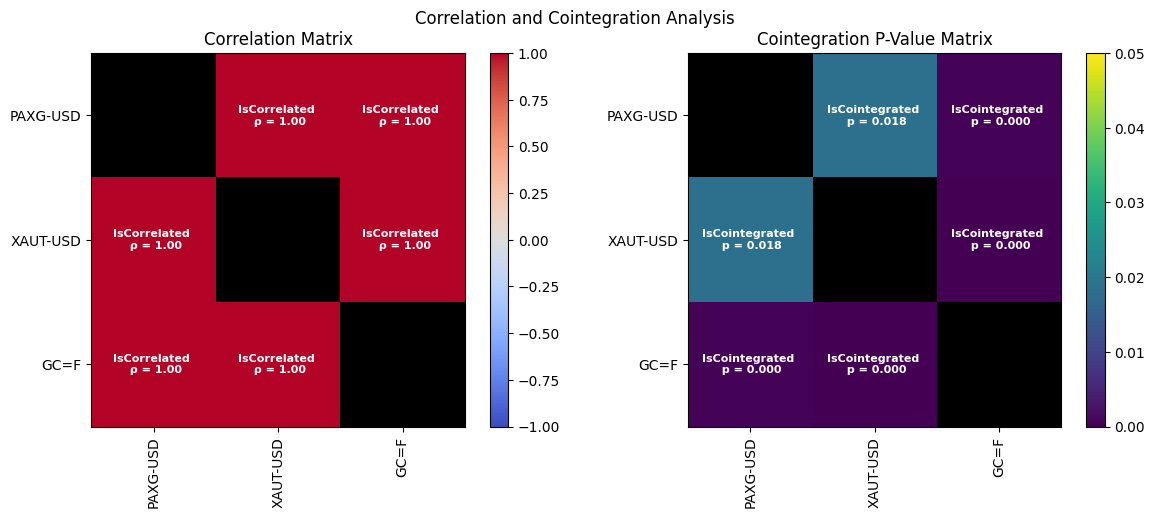

In [22]:
# correlation and cointegration matrices & charts
corr_matrix = np.zeros((len(assets), len(assets)))
coint_matrix = np.zeros((len(assets), len(assets)))

for i in range(len(assets)):
    for j in range(i+1, len(assets)):
        asset_i = data_weekdays[assets[i]]['Close']
        asset_j = data_weekdays[assets[j]]['Close']
        
        # Correlation
        corr_matrix[i, j] = asset_i.corr(asset_j)
        corr_matrix[j, i] = corr_matrix[i, j]


        # Engle-Granger (augmented) cointegration test
        score, pvalue, _ = coint(asset_i, asset_j, trend='c', method='aeg', autolag='aic')
        coint_matrix[i, j] = pvalue
        coint_matrix[j, i] = pvalue


# Plotting the correlation and cointegration matrices
plt.subplots(1, 2, figsize=(12, 5))

# Correlation Matrix with black zeros
plt.subplot(1, 2, 1)
plt.title('Correlation Matrix')
# Create custom colormap where 0 values are black

corr_cmap = plt.cm.coolwarm.copy()
corr_cmap.set_bad('black')  # Set NaN/masked values to black
# Mask zero values to make them black
corr_masked = np.ma.masked_where(np.abs(corr_matrix) < 1e-10, corr_matrix)
im1 = plt.imshow(corr_masked, cmap=corr_cmap, vmin=-1, vmax=1)
plt.xticks(range(len(assets)), assets, rotation=90)
plt.yticks(range(len(assets)), assets)
for i in range(len(assets)):
    for j in range(len(assets)):
        if i != j and abs(corr_matrix[i, j]) >= 0.7: # check for strong correlation
            plt.text(j, i, f"IsCorrelated \n ρ = {corr_matrix[i, j]:.2f}", ha='center', va='center', 
                    color='white', fontsize=8, weight='bold')

plt.colorbar(im1)  

# Cointegration Matrix with text annotations
coint_cmap = plt.cm.viridis.copy()
coint_cmap.set_bad('black')  # Set values below vmin to white
coint_masked = np.ma.masked_where(coint_matrix == 0, coint_matrix)  # Mask non-significant values
plt.subplot(1, 2, 2)
plt.title('Cointegration P-Value Matrix')
im2 = plt.imshow(coint_masked, cmap=coint_cmap, vmin=0, vmax=0.05)
plt.xticks(range(len(assets)), assets, rotation=90)
plt.yticks(range(len(assets)), assets)
# Add text annotations for significant cointegration
for i in range(len(assets)):
    for j in range(len(assets)):
        if i != j and coint_matrix[i, j] < 0.05:  # Skip diagonal and check significance
            plt.text(j, i, f'IsCointegrated \n p = {coint_matrix[i, j]:.3f}', ha='center', va='center', 
                    color='white', fontsize=8, weight='bold')
        
plt.colorbar(im2)

plt.suptitle('Correlation and Cointegration Analysis')
plt.tight_layout()
plt.show()



In [23]:
# Function to compute spread with optional beta adjustment
def compute_spread(data, asset1, asset2, beta=True):
    # Get data for the two specific assets
    df1 = data[asset1].copy()
    df2 = data[asset2].copy()
    
    # Find common dates between these two assets only
    common_dates = set(df1.index).intersection(set(df2.index))
    
    # Align both dataframes to common dates
    df1_aligned = df1.loc[df1.index.isin(common_dates)].sort_index()
    df2_aligned = df2.loc[df2.index.isin(common_dates)].sort_index()
    
    if beta:
        model = OLS(df1_aligned['Close'], add_constant(df2_aligned['Close'])).fit()
        beta_est = model.params[1]
        spread = df1_aligned['Close'] - beta_est * df2_aligned['Close']
        print(f"Estimated Beta for {asset1}-{asset2} : {beta_est:.4f}")
    else:
        spread = df1_aligned['Close'] - df2_aligned['Close']
    return spread

In [24]:
# sanity checks
print(f"length of paxgusd {data['PAXG-USD'].count()}")
print(f"length of xautusd {data['XAUT-USD'].count()}")
print(f"length of gc {data['GC=F'].count()}")
print(f"length of paxgusd weekdays {data_weekdays['PAXG-USD'].count()}")
print(f"length of xautusd weekdays {data_weekdays['XAUT-USD'].count()}")
print(f"length of gc weekdays {data_weekdays['GC=F'].count()}")
print(f"Length of spreads paxg-xaut {compute_spread(data,'PAXG-USD', 'XAUT-USD', beta=True).count()}")
print(f"Length of spreads paxg-xau {compute_spread(data_weekdays,'PAXG-USD', 'GC=F', beta=True).count()}")
print(f"Length of spreads xaut-xau {compute_spread(data_weekdays,'XAUT-USD', 'GC=F', beta=True).count()}")

length of paxgusd Close     2282
High      2282
Low       2282
Open      2282
Volume    2282
dtype: int64
length of xautusd Close     2245
High      2245
Low       2245
Open      2245
Volume    2245
dtype: int64
length of gc Close     1571
High      1571
Low       1571
Open      1571
Volume    1571
dtype: int64
length of paxgusd weekdays Close     1546
High      1546
Low       1546
Open      1546
Volume    1546
dtype: int64
length of xautusd weekdays Close     1546
High      1546
Low       1546
Open      1546
Volume    1546
dtype: int64
length of gc weekdays Close     1546
High      1546
Low       1546
Open      1546
Volume    1546
dtype: int64
Estimated Beta for PAXG-USD-XAUT-USD : 1.0052
Length of spreads paxg-xaut 2245
Estimated Beta for PAXG-USD-GC=F : 1.0058
Length of spreads paxg-xau 1546
Estimated Beta for XAUT-USD-GC=F : 1.0009
Length of spreads xaut-xau 1546


C:\Users\ayode\AppData\Local\Temp\ipykernel_38372\2568205703.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta_est = model.params[1]
C:\Users\ayode\AppData\Local\Temp\ipykernel_38372\2568205703.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta_est = model.params[1]
C:\Users\ayode\AppData\Local\Temp\ipykernel_38372\2568205703.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta_est = model.params[1]


In [25]:
# compute spreads (beta aware)

spreads = {
    'PAXG-XAUT': compute_spread(data,'PAXG-USD', 'XAUT-USD', beta=True),
    'PAXG-XAU': compute_spread(data_weekdays,'PAXG-USD', 'GC=F', beta=True),
    'XAUT-XAU': compute_spread(data_weekdays,'XAUT-USD', 'GC=F', beta=True),
}

# remove NaNs from each spread series
print(f"NaN counts before dropping: {[series.isna().sum() for series in spreads.values()]}")
spreads = {name: series.dropna() for name, series in spreads.items()}

# z-scores
rolling_zscore = {
    name: (series - series.rolling(window=window).mean()) / series.rolling(window=window).std()
    for name, series in spreads.items()
}

exp_zscore = {
    name: (series - series.ewm(span=window, adjust=False).mean()) / series.ewm(span=window, adjust=False).std()
    for name, series in spreads.items()
}

# add z-score columns directly into the existing spreads dict
for name, series in spreads.items():
    spreads[name] = series.to_frame(name='spread')
    spreads[name]['rolling_zscore'] = rolling_zscore[name]
    spreads[name]['exp_zscore'] = exp_zscore[name]

# keep existing variable names used by later cells
paxg_xaut_spread = spreads['PAXG-XAUT']
paxg_xau_spread = spreads['PAXG-XAU']
xaut_xau_spread = spreads['XAUT-XAU']


Estimated Beta for PAXG-USD-XAUT-USD : 1.0052
Estimated Beta for PAXG-USD-GC=F : 1.0058
Estimated Beta for XAUT-USD-GC=F : 1.0009
NaN counts before dropping: [np.int64(0), np.int64(0), np.int64(0)]


C:\Users\ayode\AppData\Local\Temp\ipykernel_38372\2568205703.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta_est = model.params[1]
C:\Users\ayode\AppData\Local\Temp\ipykernel_38372\2568205703.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta_est = model.params[1]
C:\Users\ayode\AppData\Local\Temp\ipykernel_38372\2568205703.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta_est = model.params[1]


Stationarity Test Results:
PAXG-XAUT: ADF Statistic = -5.1297, p-value = 0.0000
   Critical Value (1%): -3.4333
   Critical Value (5%): -2.8628
   Critical Value (10%): -2.5675
   => PAXG-XAUT is likely stationary (reject null hypothesis)
PAXG-XAU: ADF Statistic = -4.7508, p-value = 0.0001
   Critical Value (1%): -3.4346
   Critical Value (5%): -2.8634
   Critical Value (10%): -2.5678
   => PAXG-XAU is likely stationary (reject null hypothesis)
XAUT-XAU: ADF Statistic = -6.3158, p-value = 0.0000
   Critical Value (1%): -3.4347
   Critical Value (5%): -2.8634
   Critical Value (10%): -2.5678
   => XAUT-XAU is likely stationary (reject null hypothesis)


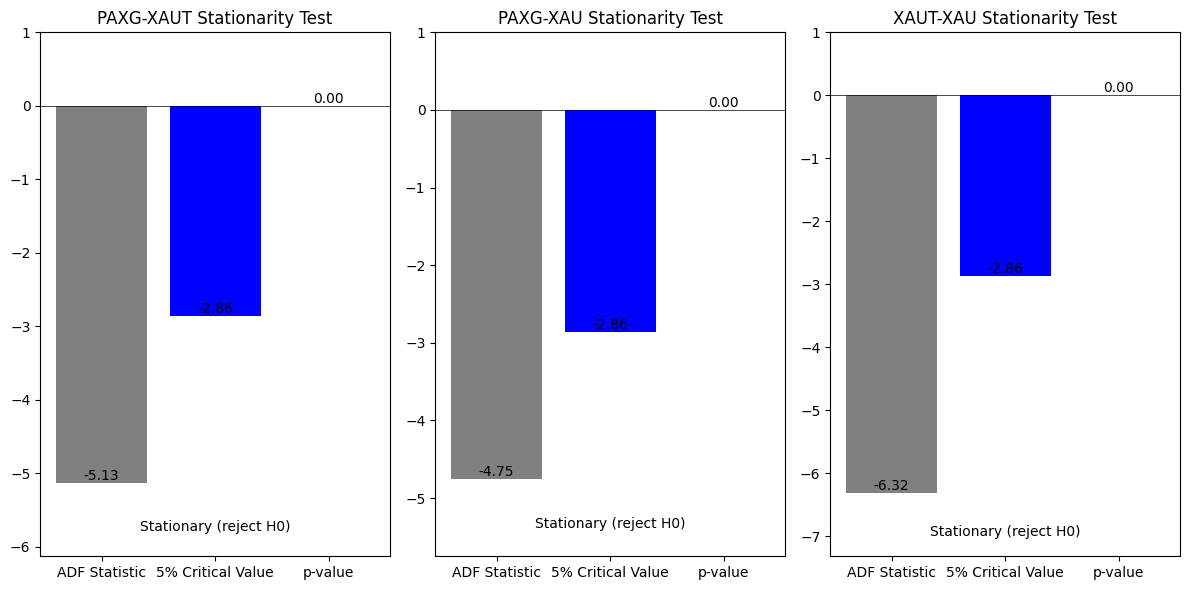

In [32]:
# stationarity test
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

stationarity = {}
for name, series in spreads.items():
    result = adfuller(series['spread'].dropna())
    stationarity[name] = {
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Critical Values': result[4]
    }

print("Stationarity Test Results:")
for name, result in stationarity.items():
    print(f"{name}: ADF Statistic = {result['ADF Statistic']:.4f}, p-value = {result['p-value']:.4f}")
    for key, value in result['Critical Values'].items():
        print(f"   Critical Value ({key}): {value:.4f}")
    if result['p-value'] < 0.05:
        print(f"   => {name} is likely stationary (reject null hypothesis)")
    else:
        print(f"   => {name} is likely non-stationary (fail to reject null hypothesis)")

# plot output for stationarity test results
plt.figure(figsize=(12, 6))
for i, (name, result) in enumerate(stationarity.items()):
    plt.subplot(1, 3, i+1)
    plt.title(f"{name} Stationarity Test")
    plt.bar(['ADF Statistic', '5% Critical Value', 'p-value'], [result['ADF Statistic'], result['Critical Values']['5%'], result['p-value']], color=['grey', 'blue', 'orange'])
    plt.axhline(0, color='black', lw=0.5)
    plt.text(0, result['ADF Statistic'], f"{result['ADF Statistic']:.2f}", ha='center', va='bottom')
    plt.text(1, result['Critical Values']['5%'], f"{result['Critical Values']['5%']:.2f}", ha='center', va='bottom')
    plt.text(2, result['p-value'], f"{result['p-value']:.2f}", ha='center', va='bottom')
    plt.ylim(min(result['ADF Statistic'], result['Critical Values']['5%'], result['p-value']) - 1, max(result['ADF Statistic'], result['Critical Values']['5%'], result['p-value']) + 1)
    plt.text(1, min(result['ADF Statistic'], result['Critical Values']['5%'], result['p-value']) - 0.5, 
             "Stationary (reject H0)" if result['p-value'] < 0.05 else "Non-Stationary (fail to reject H0)", 
             ha='center', va='top', fontsize=10, color='black' if result['p-value'] < 0.05 else 'orange')
plt.tight_layout()
plt.show()

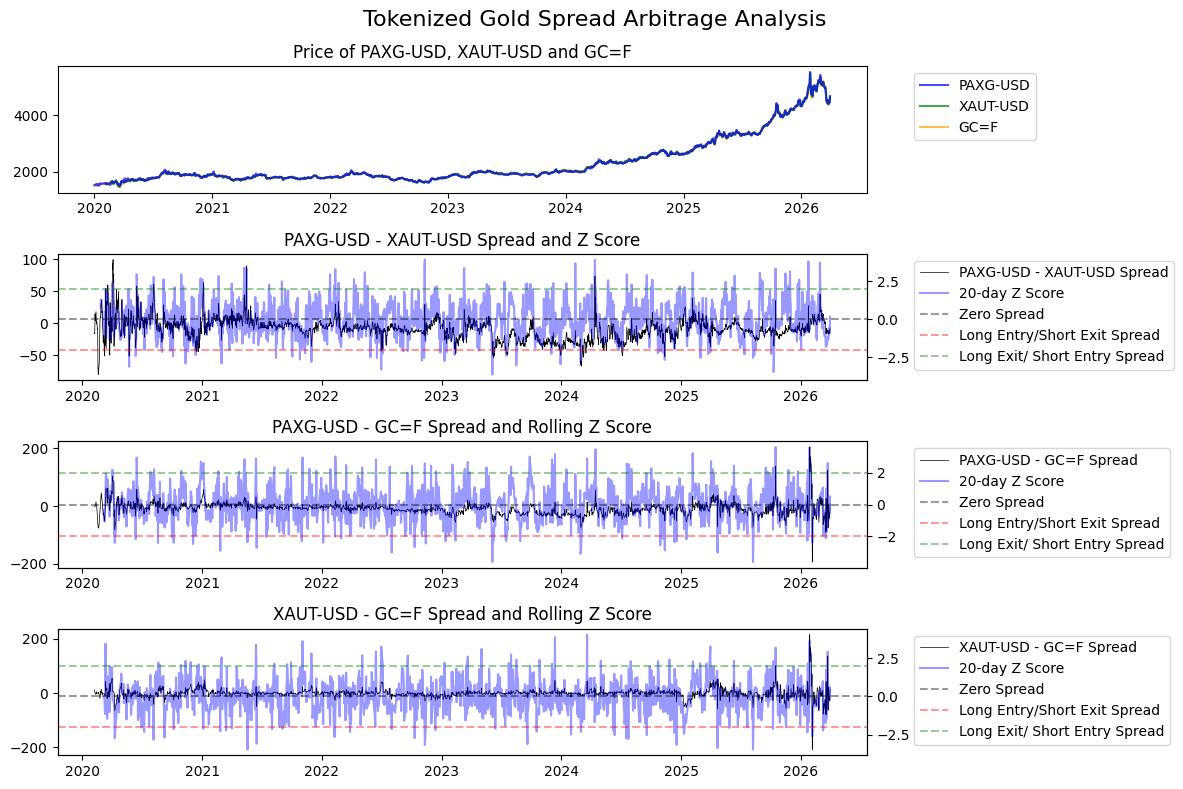

In [43]:
fig, axs = plt.subplots(4, 1, figsize=(12, 8))

axs[0].plot(data['PAXG-USD'].index, data['PAXG-USD']["Close"], label="PAXG-USD", color = "blue", alpha=0.7, zorder=3)
axs[0].plot(data['XAUT-USD'].index, data['XAUT-USD']["Close"], label="XAUT-USD", color = "green", alpha=0.7, zorder=2)
axs[0].plot(data['GC=F'].index, data['GC=F']["Close"], label="GC=F", color = "orange", alpha=0.7, zorder=1)
axs[0].set_title("Price of PAXG-USD, XAUT-USD and GC=F")
axs[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')


axs[1].plot(paxg_xaut_spread.index, paxg_xaut_spread['spread'], label="PAXG-USD - XAUT-USD Spread", color = "black", linewidth=0.5, zorder=1)
ax1_twin = axs[1].twinx()
ax1_twin.plot(paxg_xaut_spread.index, (paxg_xaut_spread['rolling_zscore']), label=f"{window}-day Z Score", color = "blue", alpha=0.4, zorder=2)
#ax1_twin.plot(paxg_xaut_spread.index, (paxg_xaut_spread['exp_zscore']), label=f"{window}-day Exp Z Score", color = "orange")
ax1_twin.axhline(0, color='black', alpha=0.4, linestyle='--', label='Zero Spread')
ax1_twin.axhline(-2, color='red', alpha=0.4, linestyle='--', label='Long Entry/Short Exit Spread')
ax1_twin.axhline(2, color='green', alpha=0.4, linestyle='--', label='Long Exit/ Short Entry Spread')
axs[1].set_title("PAXG-USD - XAUT-USD Spread and Z Score")
# Combine legends from both axes
h1, l1 = axs[1].get_legend_handles_labels()
h2, l2 = ax1_twin.get_legend_handles_labels()
axs[1].legend(h1+h2, l1+l2, bbox_to_anchor=(1.05, 1), loc='upper left')

axs[2].plot(paxg_xau_spread.index, paxg_xau_spread['spread'], label="PAXG-USD - GC=F Spread", color = "black", linewidth=0.5, zorder=1)
ax2_twin = axs[2].twinx()
ax2_twin.plot(paxg_xau_spread.index, (paxg_xau_spread['rolling_zscore']), label=f"{window}-day Z Score", color = "blue", alpha=0.4, zorder=2)
#ax2_twin.plot(paxg_xau_spread.index, (paxg_xau_spread['exp_zscore']), label=f"{window}-day Exp Z Score", color = "orange")
ax2_twin.axhline(0, color='black', alpha=0.4, linestyle='--', label='Zero Spread')
ax2_twin.axhline(-2, color='red', alpha=0.4, linestyle='--', label='Long Entry/Short Exit Spread')
ax2_twin.axhline(2, color='green', alpha=0.4, linestyle='--', label='Long Exit/ Short Entry Spread')
axs[2].set_title("PAXG-USD - GC=F Spread and Rolling Z Score")
# Combine legends from both axes
h1, l1 = axs[2].get_legend_handles_labels()
h2, l2 = ax2_twin.get_legend_handles_labels()
axs[2].legend(h1+h2, l1+l2, bbox_to_anchor=(1.05, 1), loc='upper left')

axs[3].plot(xaut_xau_spread.index, xaut_xau_spread['spread'], label="XAUT-USD - GC=F Spread", color = "black", linewidth=0.5, zorder=1)
ax3_twin = axs[3].twinx()
ax3_twin.plot(
    xaut_xau_spread.index,
    (xaut_xau_spread['rolling_zscore']),
    label="20-day Z Score",
    color="blue",
    alpha=0.4,
    zorder=2
)
# ax3_twin.plot(
#     xaut_xau_spread.index,
#     (xaut_xau_spread['exp_zscore']),
#     label="20-day Exp Z Score",
#     color="orange",
#     alpha=0.4
# )
ax3_twin.axhline(0, color='black', alpha=0.4, linestyle='--', label='Zero Spread')
ax3_twin.axhline(-2, color='red', alpha=0.4, linestyle='--', label='Long Entry/Short Exit Spread')
ax3_twin.axhline(2, color='green', alpha=0.4, linestyle='--', label='Long Exit/ Short Entry Spread')
axs[3].set_title("XAUT-USD - GC=F Spread and Rolling Z Score")
# Combine legends from both axes
h1, l1 = axs[3].get_legend_handles_labels()
h2, l2 = ax3_twin.get_legend_handles_labels()
axs[3].legend(h1+h2, l1+l2, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle("Tokenized Gold Spread Arbitrage Analysis", fontsize=16)
plt.tight_layout()
plt.show()

In [44]:
# More Params


train_start = start #"2025-01-01"
train_end = end #"2025-12-31"


window = 20
windows = [5, 10, 20, 50, 100]

# copy df and filter for training period

df = paxg_xaut_spread.copy()
df = df[(df.index >= train_start) & (df.index <= train_end)]

# trading signals generation

# z > thresh short A long B, z < thresh long A short B
thresh = 2

signals = pd.DataFrame(index=df.index)
signals['PAXG-Close'] = data['PAXG-USD']['Close']
signals['XAUT-Close'] = data['XAUT-USD']['Close']
signals['Spread'] = df['spread']
signals['Rolling Z Score'] = df['rolling_zscore']
signals['Exp Z Score'] = df['exp_zscore']
signals['Signal'] = 0
signals.loc[df['rolling_zscore'] > thresh, 'Signal'] = -1
signals.loc[df['rolling_zscore'] < -thresh, 'Signal'] = 1
signals['MA-Signal'] = 0
signals.loc[df['rolling_zscore'] > df['exp_zscore'], 'MA-Signal'] = -1
signals.loc[df['rolling_zscore'] < df['exp_zscore'], 'MA-Signal'] = 1


In [50]:
# More Params

train_start = start #"2025-01-01"
train_end = end #"2025-12-31"

window = 20
windows = [5, 10, 20, 50, 100]

# copy df and filter for training period
df = paxg_xaut_spread.copy()
df = df[(df.index >= train_start) & (df.index <= train_end)]

# trading signals generation
# z > thresh short A long B, z < thresh long A short B
thresh = 2

signals = pd.DataFrame(index=df.index)
signals['PAXG-Close'] = data['PAXG-USD']['Close'].reindex(df.index)
signals['XAUT-Close'] = data['XAUT-USD']['Close'].reindex(df.index)
signals['Spread'] = df['spread']
signals['Rolling Z Score'] = df['rolling_zscore']
signals['Exp Z Score'] = df['exp_zscore']

# Threshold crossover signal with proper entry/exit logic
signals['Signal'] = 0
z = df['rolling_zscore']
z_prev = z.shift(1)
position = 0

for i, idx in enumerate(df.index):
    z_now = z.loc[idx]
    z_yesterday = z_prev.loc[idx] if pd.notna(z_prev.loc[idx]) else None
    
    if pd.isna(z_now):
        signals.loc[idx, 'Signal'] = position
        continue
    
    # Entry logic
    if position == 0:  # No position
        if z_now > thresh:  # Enter short spread
            position = -1
        elif z_now < -thresh:  # Enter long spread
            position = 1
    
    # Exit logic
    elif position == -1:  # Currently short spread
        if z_now <= 0:  # Exit when z-score returns to zero or below
            position = 0
    
    elif position == 1:  # Currently long spread
        if z_now >= 0:  # Exit when z-score returns to zero or above
            position = 0
    
    signals.loc[idx, 'Signal'] = position

# MA crossover signal (unchanged)
signals['MA-Signal'] = 0
signals.loc[df['rolling_zscore'] > df['exp_zscore'], 'MA-Signal'] = -1
signals.loc[df['rolling_zscore'] < df['exp_zscore'], 'MA-Signal'] = 1

# return for both signal types
signals['Signal-Return'] = signals['Signal'].shift(1) * (signals['PAXG-Close'].pct_change() - signals['XAUT-Close'].pct_change())
signals['MA-Signal-Return'] = signals['MA-Signal'].shift(1) * (signals['PAXG-Close'].pct_change() - signals['XAUT-Close'].pct_change())

# now returns considering real trading conditions (entry at next open, exit at next open), with set slippage + fee assumptions 2 bps
slippage = 0.0002

signals['Signal-Return-Real-Perfect'] = signals['Signal'].shift(1) * (signals['PAXG-Close'].shift(-1).pct_change() - signals['XAUT-Close'].shift(-1).pct_change())
signals['MA-Signal-Return-Real-Perfect'] = signals['MA-Signal'].shift(1) * (signals['PAXG-Close'].shift(-1).pct_change() - signals['XAUT-Close'].shift(-1).pct_change())

signals['Signal-Return-Real-Slippage'] = signals['Signal'].shift(1) * (signals['PAXG-Close'].shift(-1).pct_change() - signals['XAUT-Close'].shift(-1).pct_change()) - slippage
signals['MA-Signal-Return-Real-Slippage'] = signals['MA-Signal'].shift(1) * (signals['PAXG-Close'].shift(-1).pct_change() - signals['XAUT-Close'].shift(-1).pct_change()) - slippage

# now considering beta instead of perfect hedge
from statsmodels.api import OLS, add_constant
model = OLS(signals['PAXG-Close'], add_constant(signals['XAUT-Close'])).fit()
beta = model.params[1]
print(f"Estimated Beta: {beta:.4f}")

signals['Beta-Adjusted Signal-Return'] = signals['Signal'].shift(1) * (signals['PAXG-Close'].pct_change() - beta * signals['XAUT-Close'].pct_change())
signals['Beta-Adjusted MA-Signal-Return'] = signals['MA-Signal'].shift(1) * (signals['PAXG-Close'].pct_change() - beta * signals['XAUT-Close'].pct_change())

Estimated Beta: 1.0052


C:\Users\ayode\AppData\Local\Temp\ipykernel_38372\3858317440.py:68: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  signals['Signal-Return-Real-Perfect'] = signals['Signal'].shift(1) * (signals['PAXG-Close'].shift(-1).pct_change() - signals['XAUT-Close'].shift(-1).pct_change())
C:\Users\ayode\AppData\Local\Temp\ipykernel_38372\3858317440.py:69: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  signals['MA-Signal-Return-Real-Perfect'] = signals['MA-Signal'].shift(1) * (signals['PAXG-Close'].shift(-1).pct_change() - signals['XAUT-Close'].shift(-1).pct_change())
C:\Users\ayode\AppData\Local\Temp\ipykerne

Text(0.5, 0, 'Date')

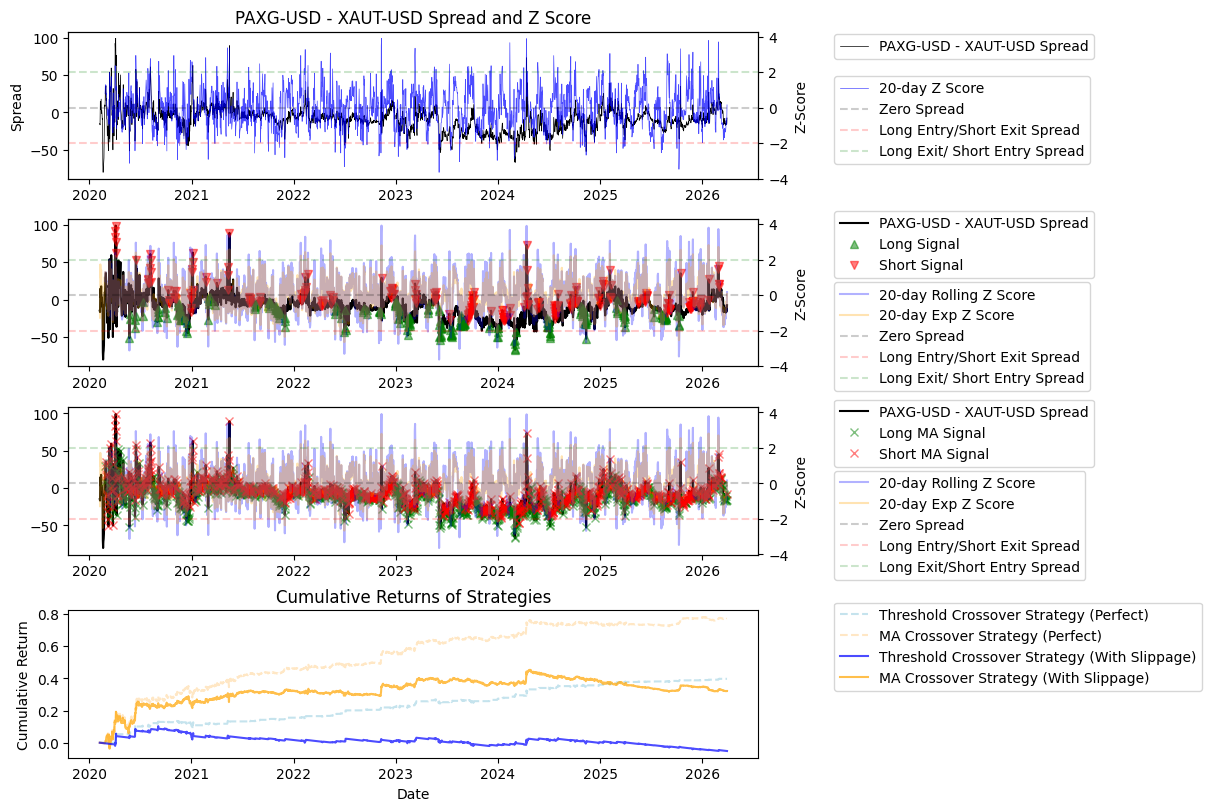

In [52]:
fig, axs = plt.subplots(4, 1, figsize=(12, 8), constrained_layout=True)

axs[0].plot(df.index, df['spread'], label="PAXG-USD - XAUT-USD Spread", color = "black", alpha=1, linewidth=0.5)
axs[0].set_ylabel("Spread")
axs[0].set_title("PAXG-USD - XAUT-USD Spread and Z Score")



ax0_twin = axs[0].twinx()
ax0_twin.plot(df.index, (df['rolling_zscore']), label=f"{window}-day Z Score", color = "blue", alpha=0.7, linewidth=0.5)
ax0_twin.axhline(0, color='black', linestyle='--', label='Zero Spread', alpha= 0.2)
ax0_twin.axhline(-2, color='red', linestyle='--', label='Long Entry/Short Exit Spread', alpha= 0.2)
ax0_twin.axhline(2, color='green', linestyle='--', label='Long Exit/ Short Entry Spread', alpha= 0.2)
ax0_twin.set_ylabel("Z-Score")
ax0_twin.set_xlabel("Date")

axs[0].legend(bbox_to_anchor=(1.1, 0.9), loc='center left')
ax0_twin.legend(bbox_to_anchor=(1.1, 0.4), loc='center left')

# threshold crossover plot
axs[1].plot(df.index, df['spread'], label="PAXG-USD - XAUT-USD Spread", color = "black")

ax1_twin = axs[1].twinx()
ax1_twin.plot(df.index, df['rolling_zscore'], label=f"{window}-day Rolling Z Score", color = "blue", alpha = 0.3)
ax1_twin.plot(df.index, df['exp_zscore'], label=f"{window}-day Exp Z Score", color = "orange", alpha = 0.3)

ax1_twin.axhline(0, color='black', linestyle='--', label='Zero Spread', alpha= 0.2)
ax1_twin.axhline(-2, color='red', linestyle='--', label='Long Entry/Short Exit Spread', alpha= 0.2)
ax1_twin.axhline(2, color='green', linestyle='--', label='Long Exit/ Short Entry Spread', alpha= 0.2)
ax1_twin.set_ylabel("Z-Score")
axs[1].plot(df.index, np.where(signals['Signal'] == 1, df['spread'], np.nan), label='Long Signal', color='green', marker='^', linestyle='None', alpha=0.5)
axs[1].plot(df.index, np.where(signals['Signal'] == -1, df['spread'], np.nan), label='Short Signal', color='red', marker='v', linestyle='None', alpha=0.5)

axs[1].legend(bbox_to_anchor=(1.1,1.1), loc='upper left')
ax1_twin.legend(bbox_to_anchor=(1.1,0.2), loc='center left')

# ma crossover plots
axs[2].plot(df.index, df['spread'], label="PAXG-USD - XAUT-USD Spread", color = "black")
ax2_twin = axs[2].twinx()
ax2_twin.plot(df.index, df['rolling_zscore'], label=f"{window}-day Rolling Z Score", color = "blue", alpha = 0.3)
ax2_twin.plot(df.index, df['exp_zscore'], label=f"{window}-day Exp Z Score", color = "orange", alpha = 0.3)
ax2_twin.axhline(0, color='black', linestyle='--', label='Zero Spread', alpha= 0.2)
ax2_twin.axhline(-2, color='red', linestyle='--', label='Long Entry/Short Exit Spread', alpha= 0.2)
ax2_twin.axhline(2, color='green', linestyle='--', label='Long Exit/Short Entry Spread', alpha= 0.2)
ax2_twin.set_ylabel("Z-Score")
axs[2].plot(df.index, np.where((signals['MA-Signal'] == 1), df['spread'], np.nan), label='Long MA Signal', color='green', marker='x', linestyle='None', alpha=0.5)
axs[2].plot(df.index, np.where((signals['MA-Signal'] == -1), df['spread'], np.nan), label='Short MA Signal', color='red', marker='x', linestyle='None', alpha=0.5)
axs[2].legend(bbox_to_anchor=(1.1,1.1), loc='upper left')
ax2_twin.legend(bbox_to_anchor=(1.1,0.2), loc='center left')

# returns comparison plots
axs[3].plot(signals.index, signals['Signal-Return-Real-Perfect'].cumsum(), label='Threshold Crossover Strategy (Perfect)', color='lightblue', linestyle='--', alpha=0.7, zorder=2)
axs[3].plot(signals.index, signals['MA-Signal-Return-Real-Perfect'].cumsum(), label='MA Crossover Strategy (Perfect)', color='navajowhite', linestyle='--', alpha=0.7, zorder=1)
axs[3].plot(signals.index, signals['Signal-Return-Real-Slippage'].cumsum(), label='Threshold Crossover Strategy (With Slippage)', color='blue', alpha=0.7, zorder=4)
axs[3].plot(signals.index, signals['MA-Signal-Return-Real-Slippage'].cumsum(), label='MA Crossover Strategy (With Slippage)', color='orange', alpha=0.7, zorder=3)
axs[3].set_title("Cumulative Returns of Strategies")
axs[3].set_ylabel("Cumulative Return")
axs[3].legend(bbox_to_anchor=(1.1,1.1), loc='upper left')


axs[3].set_xlabel("Date")

In [53]:
# More Params
train_start = start #"2025-01-01"
train_end = end #"2025-12-31"

window = 20
windows = [5, 10, 20, 50, 100]

# copy df and filter for training period
df = xaut_xau_spread.copy()
df = df[(df.index >= train_start) & (df.index <= train_end)]

# trading signals generation
# z > thresh short A long B, z < thresh long A short B
thresh = 2
signals = pd.DataFrame(index=df.index)
signals['XAUT-Close'] = data['XAUT-USD']['Close'].reindex(df.index)
signals['XAU-Close'] = data['GC=F']['Close'].reindex(df.index)
signals['Spread'] = df['spread']    
signals['Rolling Z Score'] = df['rolling_zscore']
signals['Exp Z Score'] = df['exp_zscore']
signals['Signal'] = 0
signals.loc[df['rolling_zscore'] > thresh, 'Signal'] = -1
signals.loc[df['rolling_zscore'] < -thresh, 'Signal'] = 1
signals['MA-Signal'] = 0
signals.loc[df['rolling_zscore'] > df['exp_zscore'], 'MA-Signal'] = -1
signals.loc[df['rolling_zscore'] < df['exp_zscore'], 'MA-Signal'] = 1
# return for both signal types
signals['Signal-Return'] = signals['Signal'].shift(1) * (signals['XAUT-Close'].pct_change() - signals['XAU-Close'].pct_change())
signals['MA-Signal-Return'] = signals['MA-Signal'].shift(1) * (signals['XAUT-Close'].pct_change() - signals['XAU-Close'].pct_change())
# now returns considering real trading conditions (entry at next open, exit at next open), with set slippage + fee assumptions 2 bps
slippage = 0.0002 
signals['Signal-Return-Real-Perfect'] = signals['Signal'].shift(1) * (signals['XAUT-Close'].shift(-1).pct_change() - signals['XAU-Close'].shift(-1).pct_change())
signals['MA-Signal-Return-Real-Perfect'] = signals['MA-Signal'].shift(1) * (signals['XAUT-Close'].shift(-1).pct_change() - signals['XAU-Close'].shift(-1).pct_change())
signals['Signal-Return-Real-Slippage'] = signals['Signal'].shift(1) * (signals['XAUT-Close'].shift(-1).pct_change() - signals['XAU-Close'].shift(-1).pct_change()) - slippage
signals['MA-Signal-Return-Real-Slippage'] = signals['MA-Signal'].shift(1) * (signals['XAUT-Close'].shift(-1).pct_change() - signals['XAU-Close'].shift(-1).pct_change()) - slippage
# now considering beta instead of perfect hedge     
model = OLS(signals['XAUT-Close'], add_constant(signals['XAU-Close'])).fit()
beta = model.params[1]
print(f"Estimated Beta: {beta:.4f}")
signals['Beta-Adjusted Signal-Return'] = signals['Signal'].shift(1) * (signals['XAUT-Close'].pct_change() - beta * signals['XAU-Close'].pct_change())
signals['Beta-Adjusted MA-Signal-Return'] = signals['MA-Signal'].shift(1) * (signals['XAUT-Close'].pct_change() - beta * signals['XAU-Close'].pct_change())

Estimated Beta: 1.0009


C:\Users\ayode\AppData\Local\Temp\ipykernel_38372\3620158059.py:32: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  signals['Signal-Return-Real-Perfect'] = signals['Signal'].shift(1) * (signals['XAUT-Close'].shift(-1).pct_change() - signals['XAU-Close'].shift(-1).pct_change())
C:\Users\ayode\AppData\Local\Temp\ipykernel_38372\3620158059.py:33: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  signals['MA-Signal-Return-Real-Perfect'] = signals['MA-Signal'].shift(1) * (signals['XAUT-Close'].shift(-1).pct_change() - signals['XAU-Close'].shift(-1).pct_change())
C:\Users\ayode\AppData\Local\Temp\ipykernel_

In [15]:
# **todo: add last spread plot, add returns with and without slippage, add performance metrics, add beta adjusted returns, add more window lengths for zscore, add more pairs, add cointegration test results in the charts**

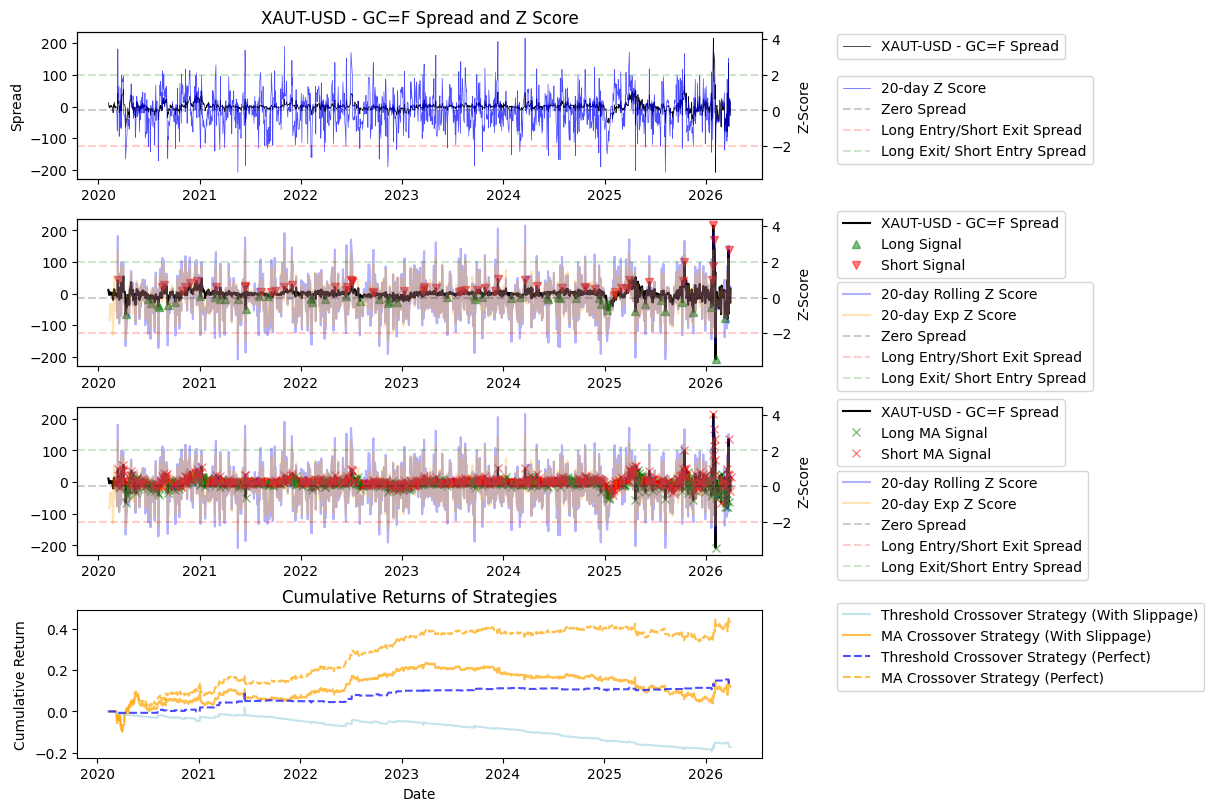

In [56]:
# Plotting
fig, axs = plt.subplots(4, 1, figsize=(12, 8), constrained_layout=True)
axs[0].plot(df.index, df['spread'], label="XAUT-USD - GC=F Spread", color = "black", alpha=1, linewidth=0.5)
axs[0].set_ylabel("Spread")
axs[0].set_title("XAUT-USD - GC=F Spread and Z Score")
ax0_twin = axs[0].twinx()
ax0_twin.plot(df.index, (df['rolling_zscore']), label=f"{window}-day Z Score", color = "blue", alpha=0.7, linewidth=0.5)
ax0_twin.axhline(0, color='black', linestyle='--', label='Zero Spread', alpha= 0.2)
ax0_twin.axhline(-2, color='red', linestyle='--', label='Long Entry/Short Exit Spread', alpha= 0.2)
ax0_twin.axhline(2, color='green', linestyle='--', label='Long Exit/ Short Entry Spread', alpha= 0.2)
ax0_twin.set_ylabel("Z-Score")
ax0_twin.set_xlabel("Date")
axs[0].legend(bbox_to_anchor=(1.1, 0.9), loc='center left')
ax0_twin.legend(bbox_to_anchor=(1.1, 0.4), loc='center left')
# threshold crossover plot  
axs[1].plot(df.index, df['spread'], label="XAUT-USD - GC=F Spread", color = "black")
ax1_twin = axs[1].twinx()
ax1_twin.plot(df.index, df['rolling_zscore'], label=f"{window}-day Rolling Z Score", color = "blue", alpha = 0.3)
ax1_twin.plot(df.index, df['exp_zscore'], label=f"{window}-day Exp Z Score", color = "orange", alpha = 0.3)
ax1_twin.axhline(0, color='black', linestyle='--', label='Zero Spread', alpha= 0.2)
ax1_twin.axhline(-2, color='red', linestyle='--', label='Long Entry/Short Exit Spread', alpha= 0.2)
ax1_twin.axhline(2, color='green', linestyle='--', label='Long Exit/ Short Entry Spread', alpha= 0.2)
ax1_twin.set_ylabel("Z-Score")  
axs[1].plot(df.index, np.where(signals['Signal'] == 1, df['spread'], np.nan), label='Long Signal', color='green', marker='^', linestyle='None', alpha=0.5)
axs[1].plot(df.index, np.where(signals['Signal'] == -1, df['spread'], np.nan), label='Short Signal', color='red', marker='v', linestyle='None', alpha=0.5)
axs[1].legend(bbox_to_anchor=(1.1,1.1), loc='upper left')
ax1_twin.legend(bbox_to_anchor=(1.1,0.2), loc='center left')
# ma crossover plots
axs[2].plot(df.index, df['spread'], label="XAUT-USD - GC=F Spread", color = "black")
ax2_twin = axs[2].twinx()
ax2_twin.plot(df.index, df['rolling_zscore'], label=f"{window}-day Rolling Z Score", color = "blue", alpha = 0.3)
ax2_twin.plot(df.index, df['exp_zscore'], label=f"{window}-day Exp Z Score", color = "orange", alpha = 0.3)
ax2_twin.axhline(0, color='black', linestyle='--', label='Zero Spread', alpha= 0.2)
ax2_twin.axhline(-2, color='red', linestyle='--', label='Long Entry/Short Exit Spread', alpha= 0.2)
ax2_twin.axhline(2, color='green', linestyle='--', label='Long Exit/Short Entry Spread', alpha= 0.2)
ax2_twin.set_ylabel("Z-Score") 
axs[2].plot(df.index, np.where((signals['MA-Signal'] == 1), df['spread'], np.nan), label='Long MA Signal', color='green', marker='x', linestyle='None', alpha=0.5)
axs[2].plot(df.index, np.where((signals['MA-Signal'] == -1), df['spread'], np.nan), label='Short MA Signal', color='red', marker='x', linestyle='None', alpha=0.5)
axs[2].legend(bbox_to_anchor=(1.1,1.1), loc='upper left')
ax2_twin.legend(bbox_to_anchor=(1.1,0.2), loc='center left')
# returns comparison plots
axs[3].plot(signals.index, signals['Signal-Return-Real-Slippage'].cumsum(), label='Threshold Crossover Strategy (With Slippage)', color='lightblue', alpha=0.7, zorder=2)
axs[3].plot(signals.index, signals['MA-Signal-Return-Real-Slippage'].cumsum(), label='MA Crossover Strategy (With Slippage)', color='orange', alpha=0.7, zorder=1)
axs[3].plot(signals.index, signals['Signal-Return-Real-Perfect'].cumsum(), label='Threshold Crossover Strategy (Perfect)', color='blue', linestyle='--', alpha=0.7, zorder=2)
axs[3].plot(signals.index, signals['MA-Signal-Return-Real-Perfect'].cumsum(), label='MA Crossover Strategy (Perfect)', color='orange', linestyle='--', alpha=0.7, zorder=1)
axs[3].set_title("Cumulative Returns of Strategies")
axs[3].set_ylabel("Cumulative Return")
axs[3].legend(bbox_to_anchor=(1.1,1.1), loc='upper left')
axs[3].set_xlabel("Date")
plt.show()

In [ ]:
# More Params
train_start = start #"2025-01-01"
train_end = end #"2025-12-31"
window = 20
windows = [5, 10, 20, 50, 100]

# copy df and filter for training period
df = paxg_xau_spread.copy()
df = df[(df.index >= train_start) & (df.index <= train_end)]
# trading signals generation
# z > thresh short A long B, z < thresh long A short B
thresh = 2
signals = pd.DataFrame(index=df.index)
signals['PAXG-Close'] = data['PAXG-USD']['Close'].reindex(df.index)
signals['XAU-Close'] = data['GC=F']['Close'].reindex(df.index)
signals['Spread'] = df['spread']
signals['Rolling Z Score'] = df['rolling_zscore']
signals['Exp Z Score'] = df['exp_zscore']
signals['Signal'] = 0
signals.loc[df['rolling_zscore'] > thresh, 'Signal'] = -1
signals.loc[df['rolling_zscore'] < -thresh, 'Signal'] = 1
signals['MA-Signal'] = 0
signals.loc[df['rolling_zscore'] > df['exp_zscore'], 'MA-Signal'] = -1
signals.loc[df['rolling_zscore'] < df['exp_zscore'], 'MA-Signal'] = 1
# return for both signal types
signals['Signal-Return'] = signals['Signal'].shift(1) * (signals['PAXG-Close'].pct_change() - signals['XAU-Close'].pct_change())
signals['MA-Signal-Return'] = signals['MA-Signal'].shift(1) * (signals['PAXG-Close'].pct_change() - signals['XAU-Close'].pct_change())
# now returns considering real trading conditions (entry at next open, exit at next open), with set slippage + fee assumptions 2 bps
slippage = 0.0002
signals['Signal-Return-Real-Perfect'] = signals['Signal'].shift(1) * (signals['PAXG-Close'].shift(-1).pct_change() - signals['XAU-Close'].shift(-1).pct_change())
#signals['MA-Signal-Return-Real-Perfect'] = signals['MA-Signal'].shifgiott(1) * (signals['PAXG-Close'].shift(-1).pct_change() - signals['XAU-Close'].shift(-1).pct_change())
signals['Signal-Return-Real-Slippage'] = signals['Signal'].shift(1) * (signals['PAXG-Close'].shift(-1).pct_change() - signals['XAU-Close'].shift(-1).pct_change()) - slippage
#signals['MA-Signal-Return-Real-Slippage'] = signals['MA-Signal'].shift(1) * (signals['PAXG-Close'].shift(-1).pct_change() - signals['XAU-Close'].shift(-1).pct_change()) - slippage
# now considering beta instead of perfect hedge
model = OLS(signals['PAXG-Close'], add_constant(signals['XAU-Close'])).fit()
beta = model.params[1]
print(f"Estimated Beta: {beta:.4f}")
signals['Beta-Adjusted Signal-Return-Perfect'] = signals['Signal'].shift(1) * (signals['PAXG-Close'].pct_change() - beta * signals['XAU-Close'].pct_change())
signals['Beta-Adjusted Signal-Return-Slippage'] = signals['MA-Signal'].shift(1) * (signals['PAXG-Close'].pct_change() - beta * signals['XAU-Close'].pct_change()) - slippage

Estimated Beta: 1.0058


C:\Users\ayode\AppData\Local\Temp\ipykernel_38372\2809249647.py:30: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  signals['Signal-Return-Real-Perfect'] = signals['Signal'].shift(1) * (signals['PAXG-Close'].shift(-1).pct_change() - signals['XAU-Close'].shift(-1).pct_change())
C:\Users\ayode\AppData\Local\Temp\ipykernel_38372\2809249647.py:32: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  signals['Signal-Return-Real-Slippage'] = signals['Signal'].shift(1) * (signals['PAXG-Close'].shift(-1).pct_change() - signals['XAU-Close'].shift(-1).pct_change()) - slippage
C:\Users\ayode\AppData\Local\Temp\ipyk

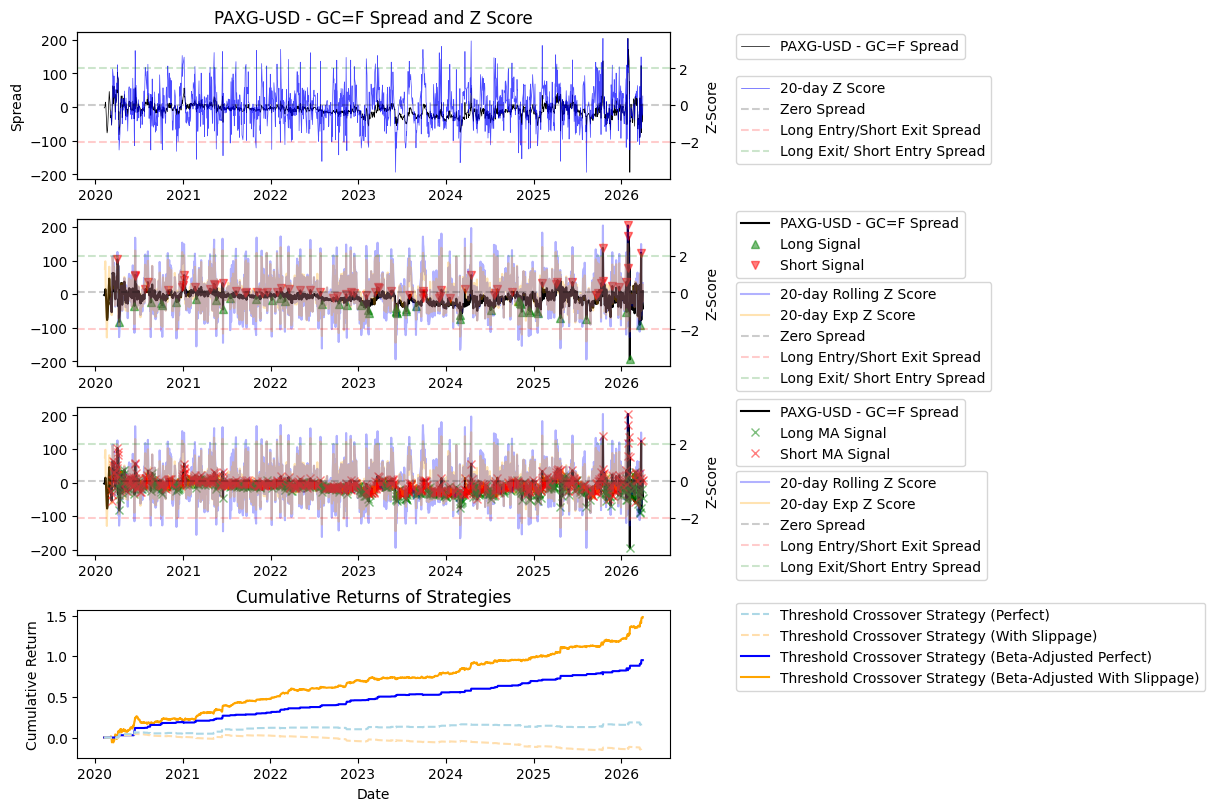

In [64]:
# Plotting
fig, axs = plt.subplots(4, 1, figsize=(12, 8), constrained_layout=True)
axs[0].plot(df.index, df['spread'], label="PAXG-USD - GC=F Spread", color = "black", alpha=1, linewidth=0.5)
axs[0].set_ylabel("Spread")
axs[0].set_title("PAXG-USD - GC=F Spread and Z Score")
ax0_twin = axs[0].twinx()
ax0_twin.plot(df.index, (df['rolling_zscore']), label=f"{window}-day Z Score", color = "blue", alpha=0.7, linewidth=0.5)
ax0_twin.axhline(0, color='black', linestyle='--', label='Zero Spread', alpha= 0.2)
ax0_twin.axhline(-2, color='red', linestyle='--', label='Long Entry/Short Exit Spread', alpha= 0.2)
ax0_twin.axhline(2, color='green', linestyle='--', label='Long Exit/ Short Entry Spread', alpha= 0.2)
ax0_twin.set_ylabel("Z-Score")
ax0_twin.set_xlabel("Date")
axs[0].legend(bbox_to_anchor=(1.1, 0.9), loc='center left')
ax0_twin.legend(bbox_to_anchor=(1.1, 0.4), loc='center left')
# threshold crossover plot
axs[1].plot(df.index, df['spread'], label="PAXG-USD - GC=F Spread", color = "black")
ax1_twin = axs[1].twinx()
ax1_twin.plot(df.index, df['rolling_zscore'], label=f"{window}-day Rolling Z Score", color = "blue", alpha = 0.3)
ax1_twin.plot(df.index, df['exp_zscore'], label=f"{window}-day Exp Z Score", color = "orange", alpha = 0.3)
ax1_twin.axhline(0, color='black', linestyle='--', label='Zero Spread', alpha= 0.2)
ax1_twin.axhline(-2, color='red', linestyle='--', label='Long Entry/Short Exit Spread', alpha= 0.2)
ax1_twin.axhline(2, color='green', linestyle='--', label='Long Exit/ Short Entry Spread', alpha= 0.2)
ax1_twin.set_ylabel("Z-Score")
axs[1].plot(df.index, np.where(signals['Signal'] == 1, df['spread'], np.nan), label='Long Signal', color='green', marker='^', linestyle='None', alpha=0.5)
axs[1].plot(df.index, np.where(signals['Signal'] == -1, df['spread'], np.nan), label='Short Signal', color='red', marker='v', linestyle='None', alpha=0.5)
axs[1].legend(bbox_to_anchor=(1.1,1.1), loc='upper left')
ax1_twin.legend(bbox_to_anchor=(1.1,0.2), loc='center left')
# ma crossover plots
axs[2].plot(df.index, df['spread'], label="PAXG-USD - GC=F Spread", color = "black")
ax2_twin = axs[2].twinx()
ax2_twin.plot(df.index, df['rolling_zscore'], label=f"{window}-day Rolling Z Score", color = "blue", alpha = 0.3)
ax2_twin.plot(df.index, df['exp_zscore'], label=f"{window}-day Exp Z Score", color = "orange", alpha = 0.3)
ax2_twin.axhline(0, color='black', linestyle='--', label='Zero Spread', alpha= 0.2)
ax2_twin.axhline(-2, color='red', linestyle='--', label='Long Entry/Short Exit Spread', alpha= 0.2)
ax2_twin.axhline(2, color='green', linestyle='--', label='Long Exit/Short Entry Spread', alpha= 0.2)
ax2_twin.set_ylabel("Z-Score")
axs[2].plot(df.index, np.where((signals['MA-Signal'] == 1), df['spread'], np.nan), label='Long MA Signal', color='green', marker='x', linestyle='None', alpha=0.5)
axs[2].plot(df.index, np.where((signals['MA-Signal'] == -1), df['spread'], np.nan), label='Short MA Signal', color='red', marker='x', linestyle='None', alpha=0.5)
axs[2].legend(bbox_to_anchor=(1.1,1.1), loc='upper left')
ax2_twin.legend(bbox_to_anchor=(1.1,0.2), loc='center left')
# returns comparison plots
axs[3].plot(signals.index, signals['Signal-Return-Real-Perfect'].cumsum(), label='Threshold Crossover Strategy (Perfect)', color='lightblue', linestyle='--', alpha=1, zorder=4)
axs[3].plot(signals.index, signals['Signal-Return-Real-Slippage'].cumsum(), label='Threshold Crossover Strategy (With Slippage)', color='navajowhite', linestyle='--', alpha=1, zorder=3)
axs[3].plot(signals.index, signals['Beta-Adjusted Signal-Return-Perfect'].cumsum(), label='Threshold Crossover Strategy (Beta-Adjusted Perfect)', color='blue', alpha=1, zorder=2) 
axs[3].plot(signals.index, signals['Beta-Adjusted Signal-Return-Slippage'].cumsum(), label='Threshold Crossover Strategy (Beta-Adjusted With Slippage)', color='orange', alpha=1, zorder=1)

axs[3].set_title("Cumulative Returns of Strategies")    
axs[3].set_ylabel("Cumulative Return")
axs[3].legend(bbox_to_anchor=(1.1,1.1), loc='upper left')
axs[3].set_xlabel("Date")
plt.show()